# **Hypothesis-driven EDA for California Housing**

## INFO 442  Group 5 Shuyang Zhang 320230942711

from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

homes = fetch_california_housing(as_frame=True).frame

print("Shape:", homes.shape)
homes.head()

### **1. Spot the suspicious column. For every numeric column compute max / median. Which column's maximum is most wildly inflated relative to its typical value, and how does that connect to Section 5? (Hint: homes.max() / homes.median().)**

In [14]:
print("Column names:", homes.columns.tolist())
print("MAX / MEDIAN RATIOS")

for col in homes.columns:
    max_val = homes[col].max()
    median_val = homes[col].median()
    ratio = max_val / median_val
    print(f"{col:15s}: max={max_val:10.2f}, median={median_val:8.2f}, ratio={ratio:.2f}")

print("MOST INFLATED COLUMN")
ratios = homes.max() / homes.median()
most_inflated = ratios.idxmax()
print(f"{most_inflated} has the highest ratio: {ratios.max():.2f}")

Column names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
MAX / MEDIAN RATIOS
MedInc         : max=     15.00, median=    3.53, ratio=4.24
HouseAge       : max=     52.00, median=   29.00, ratio=1.79
AveRooms       : max=    141.91, median=    5.23, ratio=27.14
AveBedrms      : max=     34.07, median=    1.05, ratio=32.48
Population     : max=  35682.00, median= 1166.00, ratio=30.60
AveOccup       : max=   1243.33, median=    2.82, ratio=441.19
Latitude       : max=     41.95, median=   34.26, ratio=1.22
Longitude      : max=   -114.31, median= -118.49, ratio=0.96
MedHouseVal    : max=      5.00, median=    1.80, ratio=2.78
MOST INFLATED COLUMN
AveOccup has the highest ratio: 441.19


**Answer:**

`AveOccup` has the highest max/median ratio, meaning its maximum value is 441 times larger than its typical value. This connects to Section 5's Hook B (impossible outliers), where tiny block groups with very few households cause the average household size to explode to implausible numbers. These extreme values are not data errors but real artifacts of the aggregation method, yet they can still distort analysis if not handled properly.

### **2. Hypothesis — older houses are cheaper. Test HouseAge vs MedHouseVal: compute their correlation and make a scatter plot. Is the relationship strong, weak, or basically absent? State your verdict.**

Correlation: 0.106


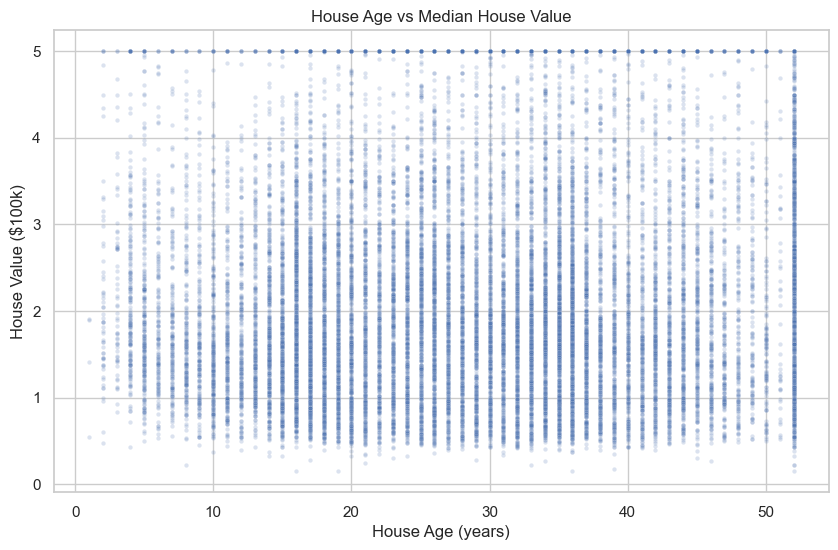

In [20]:
correlation = homes["HouseAge"].corr(homes["MedHouseVal"])
print(f"Correlation: {correlation:.3f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=homes, x="HouseAge", y="MedHouseVal", alpha=0.2, s=10)
plt.title("House Age vs Median House Value")
plt.xlabel("House Age (years)")
plt.ylabel("House Value ($100k)")
plt.show()

**Answer:**

Correlation is 0.106 (slightly positive). The relationship is very weak. House age has almost no linear relationship with house value.

### **3. Hypothesis — crowded areas differ in price. Create a categorical column crowded = homes["AveOccup"] > 3, then make a box plot of MedHouseVal split by crowded, and compare the group medians. Does crowding relate to value?**

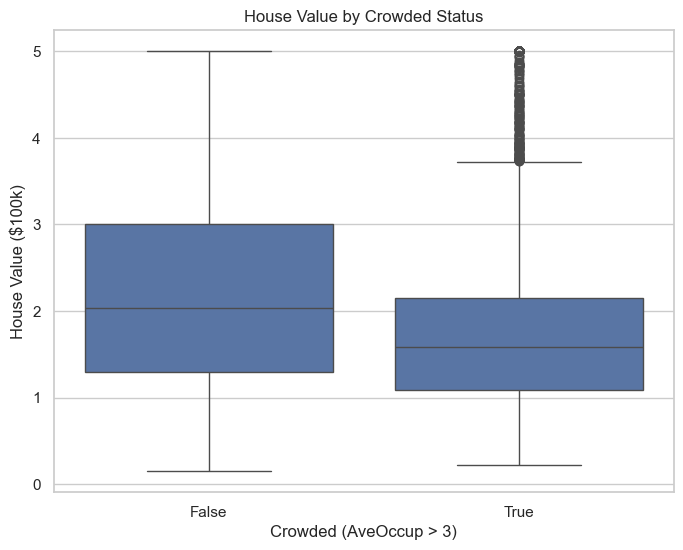

Crowded median: 1.585
Not crowded median: 2.037


In [25]:
homes["crowded"] = homes["AveOccup"] > 3

plt.figure(figsize=(8, 6))
sns.boxplot(data=homes, x="crowded", y="MedHouseVal")
plt.title("House Value by Crowded Status")
plt.xlabel("Crowded (AveOccup > 3)")
plt.ylabel("House Value ($100k)")
plt.show()

crowded_median = homes[homes["crowded"]]["MedHouseVal"].median()
not_crowded_median = homes[~homes["crowded"]]["MedHouseVal"].median()
print(f"Crowded median: {crowded_median:.3f}")
print(f"Not crowded median: {not_crowded_median:.3f}")

**Answer:**

Crowded median (1.585) is significantly lower than not crowded median (2.037). This suggests crowding (AveOccup > 3) is associated with lower house values.

### **4. Re-draw the map for income. Repeat the Section 4 location plot but colour by MedInc instead of value. In one sentence, how does the income map compare to the value map — and what does that similarity suggest?**

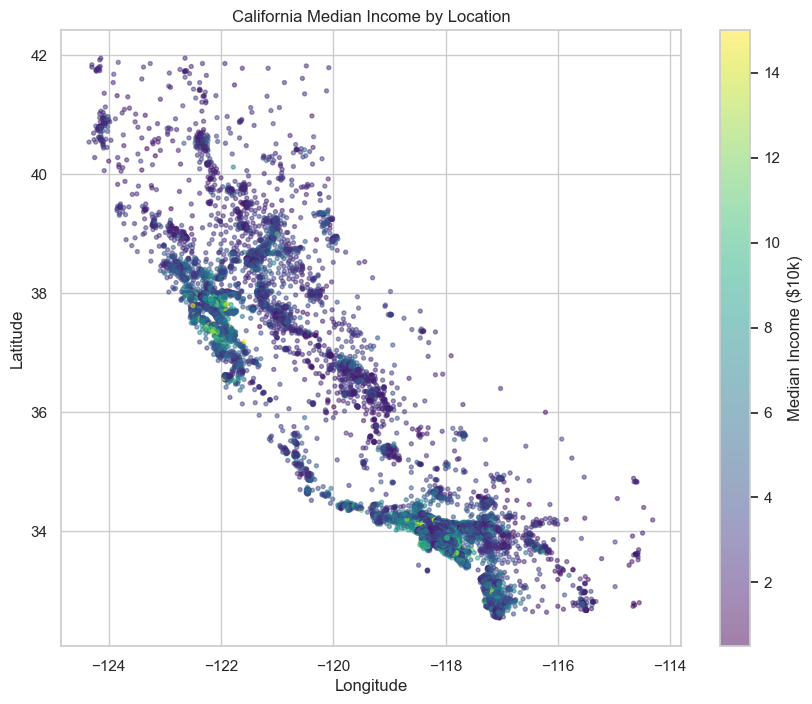

In [29]:
plt.figure(figsize=(10, 8))
sc = plt.scatter(homes["Longitude"], homes["Latitude"], 
                 c=homes["MedInc"], cmap="viridis", s=8, alpha=0.5)
plt.colorbar(sc, label="Median Income ($10k)")
plt.title("California Median Income by Location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

**Answer:**

The income map closely mirrors the house value map, with higher incomes along the coast and in major metro areas, suggesting income is a strong driver of housing prices.

### **5. The cap, quantified. What percentage of all neighbourhoods sit exactly at the $500k cap? (Hint: count rows at the max, divide by len(homes).) Why would this percentage matter to someone training a price-prediction model?**

In [33]:
cap = homes["MedHouseVal"].max()
capped_count = (homes["MedHouseVal"] == cap).sum()
percentage = (capped_count / len(homes)) * 100
print(f"Neighborhoods at cap (${cap*100:.0f}k): {capped_count} out of {len(homes)} ({percentage:.2f}%)")

Neighborhoods at cap ($500k): 965 out of 20640 (4.68%)


**Answer:**

Approximately 4.68% of neighborhoods (965 out of 20,640) sit exactly at the `$500k` cap.

This matters because a price-prediction model trained on this data will never learn to predict values above `$500k`, and will systematically underestimate the true value of expensive properties. The cap creates censored data that biases predictions downward for high-value neighborhoods. Any model trained on this data would struggle to generalize to markets where houses exceed `$500k`.00k.

### **6. Challenge — your own investigation. Form one hypothesis this notebook didn't test (e.g. about AveBedrms, Population, or combining columns), then run the full loop: hypothesis → plot → supporting number → verdict → one caveat that could undermine it.**

**Hypothesis:** 

Neighborhoods with more bedrooms per room (higher bedroom ratio) have lower house values, as this may indicate older or smaller homes where bedrooms take up a larger proportion of total rooms.

Correlation: -0.256


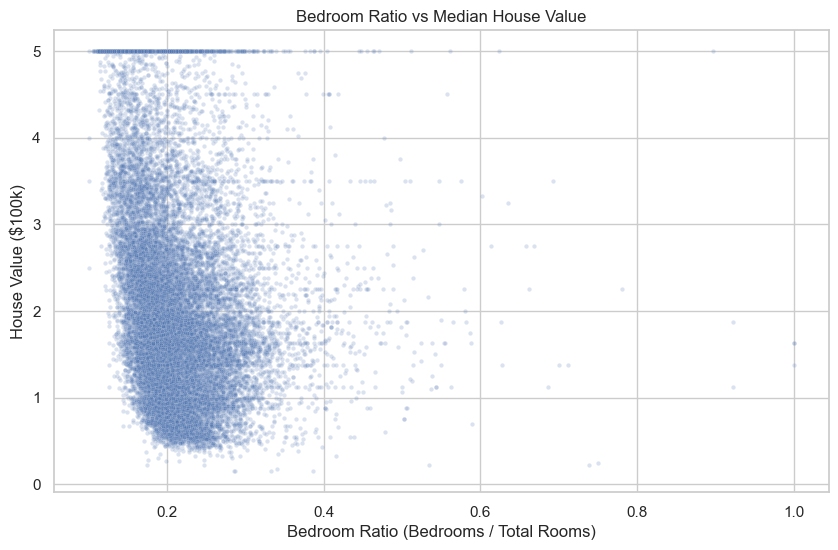

In [44]:
homes["bedroom_ratio"] = homes["AveBedrms"] / homes["AveRooms"]

correlation = homes["bedroom_ratio"].corr(homes["MedHouseVal"])
print(f"Correlation: {correlation:.3f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=homes, x="bedroom_ratio", y="MedHouseVal", alpha=0.2, s=10)
plt.title("Bedroom Ratio vs Median House Value")
plt.xlabel("Bedroom Ratio (Bedrooms / Total Rooms)")
plt.ylabel("House Value ($100k)")
plt.show()

Correlation = -0.256

Higher bedroom ratio is associated with lower house values, supporting the hypothesis. Homes with proportionally more bedrooms tend to have lower values.Correlation does not imply causation. Other factors like location, income, or house age could be driving this relationship. Additionally, extreme outliers in bedroom ratio may distort the result.